<a href="https://colab.research.google.com/github/arxsyy/MachineLearning_2026/blob/main/KUIS1_244107020133_MarsyaliaFernanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# 1. Inspeksi profile data
df.info()

# 2. Cek variabel yang memiliki nilai yang hilang dan berapa jumlahnya
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


2. variabel yang memiliki nilai yang hilang (missing value) adalah workclass dengan jumlah 963, occupation dengan jumlah 966, dan native-country dengan jumlah 274

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [9]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# 1. Imputasi missing value dengan modus
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

# 2. Cek kembali missing value
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [10]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Inspeksi semua fitur kualitatif
kolom_kualitatif = df.select_dtypes(include='object').columns

for kolom in kolom_kualitatif:
    print(f"\n{kolom}:")
    print(df[kolom].value_counts())


workclass:
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation:
occupation
Prof-specialty     

In [11]:
# Mengganti value yang tidak sesuai menjadi 'Others'
df['workclass'] = df['workclass'].replace('?', 'Others')
df['occupation'] = df['occupation'].replace('?', 'Others')
df['native-country'] = df['native-country'].replace('?', 'Others')

# Menyesuaikan duplikasi penulisan pada income
df['income'] = df['income'].replace({
    '<=50K.': '<=50K',
    '>50K.': '>50K'
})

# Cek kembali fitur kualitatif
for kolom in kolom_kualitatif:
    print(f"\n{kolom}:")
    print(df[kolom].value_counts())


workclass:
workclass
Private             34869
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Others               1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

marital-status:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation:
occupation
Prof-specialty     

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

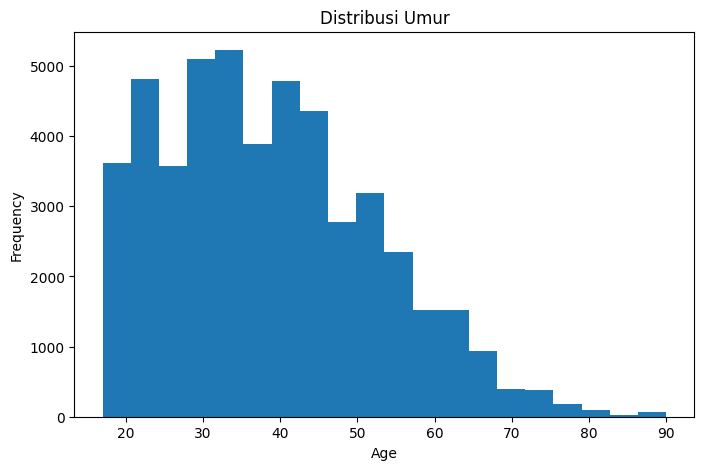

In [12]:
# Jawab 1.1 - Histrogram

# Histogram age
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20)

plt.title('Distribusi Umur')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

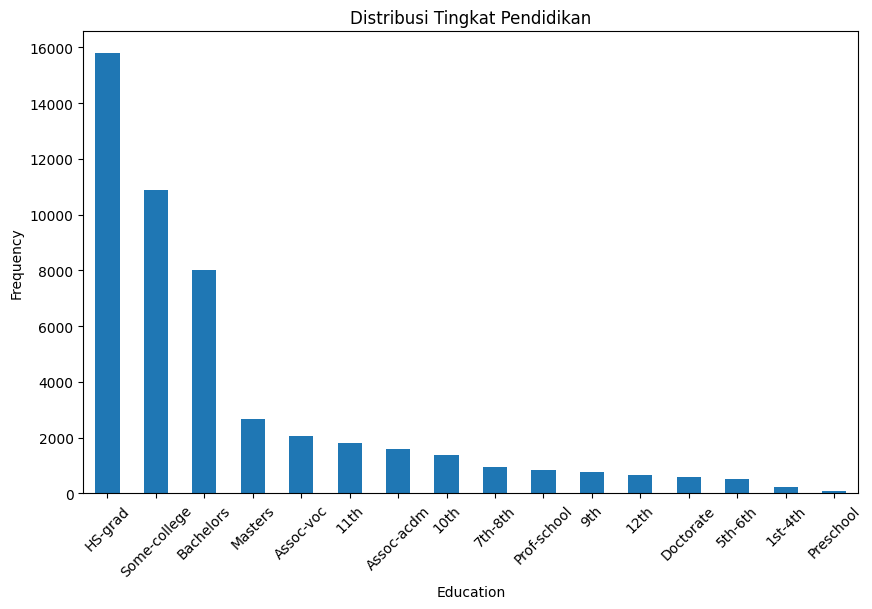

In [13]:
# Jawab 1.2 - Barchart

# Bar chart education
education_counts = df['education'].value_counts()

plt.figure(figsize=(10, 6))
education_counts.plot(kind='bar')

plt.title('Distribusi Tingkat Pendidikan')
plt.xlabel('Education')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

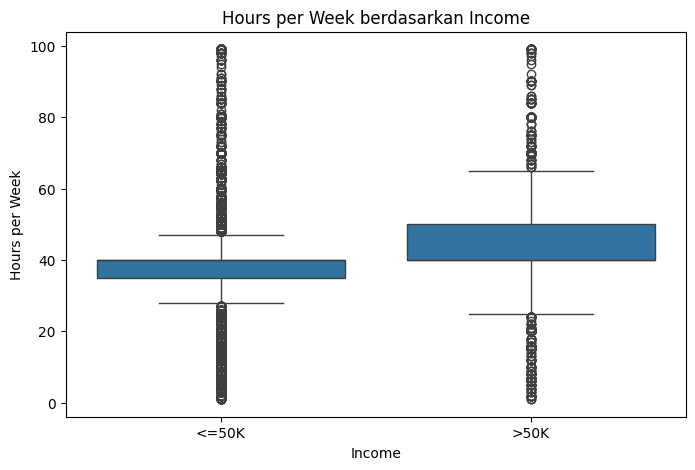

In [14]:
# Jawab 1.3 - Boxplot

# Boxplot income terhadap hours-per-week
plt.figure(figsize=(8, 5))

sns.boxplot(x='income', y='hours-per-week', data=df)

plt.title('Hours per Week berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')

plt.show()

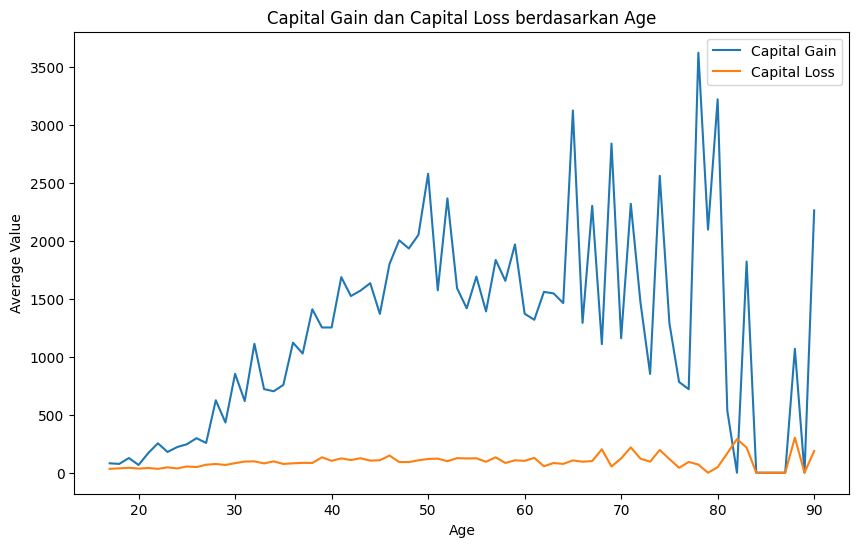

In [15]:
# Jawab 1.4 - Lineplot

# Mengelompokkan data berdasarkan age
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

# Lineplot
plt.figure(figsize=(10, 6))

plt.plot(age_capital.index, age_capital['capital-gain'], label='Capital Gain')
plt.plot(age_capital.index, age_capital['capital-loss'], label='Capital Loss')

plt.title('Capital Gain dan Capital Loss berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Average Value')
plt.legend()

plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawab dengan komentar python

'''
1. Distribusi data age cenderung right-skewed (miring ke kanan).
Sebagian besar data berada pada usia muda hingga menengah,
sedangkan jumlah data semakin sedikit pada usia yang lebih tua.

2. Jika terdapat missing value pada variabel age, saya akan menggunakan median.
Median dipilih karena distribusi age tidak simetris dan cenderung right-skewed,
sehingga median lebih tahan terhadap nilai ekstrem dibandingkan mean.
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

In [16]:
# Menghitung jumlah outlier hours-per-week pada setiap kategori income

for kategori in df['income'].unique():
    data = df[df['income'] == kategori]['hours-per-week']

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[(data < batas_bawah) | (data > batas_atas)]

    print(f"Income {kategori}")
    print(f"Jumlah outlier: {len(outlier)}")
    print()

Income <=50K
Jumlah outlier: 11706

Income >50K
Jumlah outlier: 781



In [ ]:
'''
1. Distribusi data age cenderung right-skewed (miring ke kanan).
Sebagian besar data berada pada usia muda hingga menengah,
sedangkan jumlah data semakin sedikit pada usia yang lebih tua.

2. Jika terdapat missing value pada variabel age, saya akan menggunakan median.
Median dipilih karena distribusi age tidak simetris dan cenderung right-skewed,
sehingga median lebih tahan terhadap nilai ekstrem dibandingkan mean.

3. Berdasarkan perhitungan IQR pada hours-per-week:
- Income <=50K memiliki 11.706 outlier.
- Income >50K memiliki 781 outlier.

Jadi, kategori income <=50K memiliki jumlah outlier paling banyak.
'''

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [17]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Encoding variabel sex
df['sex'] = df['sex'].map({
    'Female': 0,
    'Male': 1
})

# Encoding variabel target income
df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

# Cek hasil encoding
print(df['sex'].value_counts())
print()
print(df['income'].value_counts())

sex
1    32650
0    16192
Name: count, dtype: int64

income
0    37155
1    11687
Name: count, dtype: int64


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

In [20]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Memilih variabel untuk analisis korelasi
kolom_korelasi = [
    'age',
    'education-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
    'income'
]

# Menghitung korelasi
korelasi = df[kolom_korelasi].corr()

# Menampilkan matriks korelasi
korelasi

,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.000000,0.030940,0.071558,0.077229,0.056944,0.230369
education-num,0.030940,1.000000,0.143689,0.125146,0.080972,0.332613
hours-per-week,0.071558,0.143689,1.000000,0.082157,0.054467,0.227687
capital-gain,0.077229,0.125146,0.082157,1.000000,-0.031441,0.223013
capital-loss,0.056944,0.080972,0.054467,-0.031441,1.000000,0.147554
income,0.230369,0.332613,0.227687,0.223013,0.147554,1.000000


In [ ]:
# Hasil analisis jelaskan pada cell ini

'''
Berdasarkan hasil korelasi:
1. education-num memiliki korelasi positif paling kuat terhadap income,
yaitu sebesar 0.333.
2. age memiliki korelasi positif terhadap income sebesar 0.230.
3. hours-per-week memiliki korelasi positif terhadap income sebesar 0.228.
4. capital-gain memiliki korelasi positif terhadap income sebesar 0.223.
5. capital-loss memiliki korelasi positif terhadap income sebesar 0.148.
Secara keseluruhan, semua variabel memiliki korelasi positif terhadap income,
tetapi korelasinya tergolong lemah. Variabel yang memiliki hubungan paling
besar dengan income adalah education-num.
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [21]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


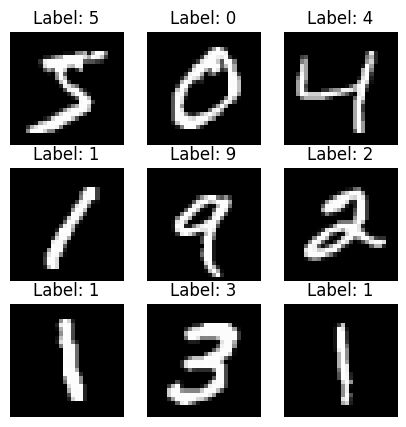

In [22]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [23]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

import cv2

# Membuat array kosong untuk hasil upsampling
X_test_upsampled = np.empty((10000, 32, 32), dtype=np.uint8)

# Upsampling seluruh data test
for i in range(len(X_test)):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32))

# Cek ukuran hasil
print("Shape setelah upsampling:", X_test_upsampled.shape)

Shape setelah upsampling: (10000, 32, 32)


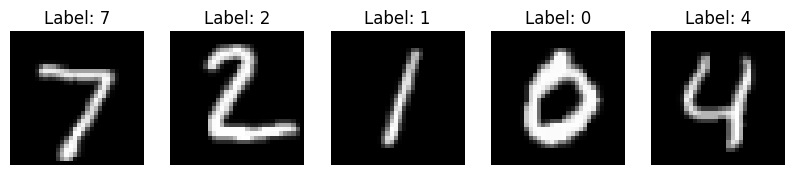

In [24]:
# Menampilkan 5 hasil upsampling
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")

plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [25]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Normalisasi nilai piksel menjadi rentang 0-1
X_test_normalized = X_test_upsampled.astype('float32') / 255.0

# Cek hasil normalisasi
print("Nilai minimum:", X_test_normalized.min())
print("Nilai maksimum:", X_test_normalized.max())
print("Shape:", X_test_normalized.shape)

Nilai minimum: 0.0
Nilai maksimum: 1.0
Shape: (10000, 32, 32)


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [26]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

# Membuat array kosong untuk menampung hasil flatten
X_test_flatten = np.empty((10000, 1024), dtype=np.float32)

# Mengubah setiap citra 32x32 menjadi array 1 dimensi
for i in range(len(X_test_normalized)):
    X_test_flatten[i] = X_test_normalized[i].flatten()

# Cek hasil
print("Shape setelah flatten:", X_test_flatten.shape)

Shape setelah flatten: (10000, 1024)
